In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
import warnings

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')


In [18]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
PROJECT_DIR = "/content/drive/MyDrive/Meat_Freshness_Project"
os.makedirs(PROJECT_DIR, exist_ok=True)

print("Project directory:", PROJECT_DIR)


Project directory: /content/drive/MyDrive/Meat_Freshness_Project


In [69]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
import numpy as np
import pandas as pd

def classification_report(y_true, y_pred, num_params=None):
    classes = np.unique(y_true)
    precision = precision_score(y_true, y_pred, labels=classes, average=None) * 100
    recall = recall_score(y_true, y_pred, labels=classes, average=None) * 100
    f1 = f1_score(y_true, y_pred, labels=classes, average=None) * 100
    accuracy = accuracy_score(y_true, y_pred) * 100

    cm = confusion_matrix(y_true, y_pred, labels=classes)
    specificity = []
    for i in range(len(classes)):
        tn = np.sum(np.delete(np.delete(cm, i, axis=0), i, axis=1))
        fp = np.sum(np.delete(cm[:, i], i))
        specificity.append(tn / (tn + fp) * 100 if (tn + fp) > 0 else 0)

    data = {
        'Precision (%)': precision,
        'Sensitivity (%) (Recall)': recall,
        'Specificity (%)': specificity,
        'F1-Score (%)': f1,
    }

    df_metrics = pd.DataFrame(data, index=classes).T
    for col in df_metrics.columns:
        df_metrics[col] = df_metrics[col].map(lambda x: f"{x:.2f}")

    print("Precision\tRecall\tSpecificity\tF1\t#Params\tAccuracy")
    print("\t".join(df_metrics.loc['Precision (%)']) + "\t" +
          "\t".join(df_metrics.loc['Sensitivity (%) (Recall)']) + "\t" +
          "\t".join(df_metrics.loc['Specificity (%)']) + "\t" +
          "\t".join(df_metrics.loc['F1-Score (%)']) + "\t" +
          str(num_params) + "\t" +
          f"{accuracy:.2f}")


In [70]:
valid_generator.reset()
y_pred_probs = model.predict(valid_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = valid_generator.classes

classification_report(y_true, y_pred, num_params=model.count_params())

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step
Precision	Recall	Specificity	F1	#Params	Accuracy
77.89	78.38	99.12	83.15	72.96	98.25	84.62	89.04	99.70	80.43	75.57	98.68	19587	83.37


In [21]:
def extract_from_split(folder_path):
    data = []
    if not os.path.exists(folder_path):
        print(f"Directory does not exist: {folder_path}")
        return pd.DataFrame(columns=["path", "label"])

    for filename in os.listdir(folder_path):
        if filename.endswith(".jpg"):
            label = filename.split("-")[0].upper()
            data.append({
                "path": folder_path + "/" + filename,
                "label": label
            })
    return pd.DataFrame(data)

df_train = extract_from_split("/content/drive/MyDrive/archive/Meat Freshness.v1-new-dataset.multiclass/train")
df_valid = extract_from_split("/content/drive/MyDrive/archive/Meat Freshness.v1-new-dataset.multiclass/valid")


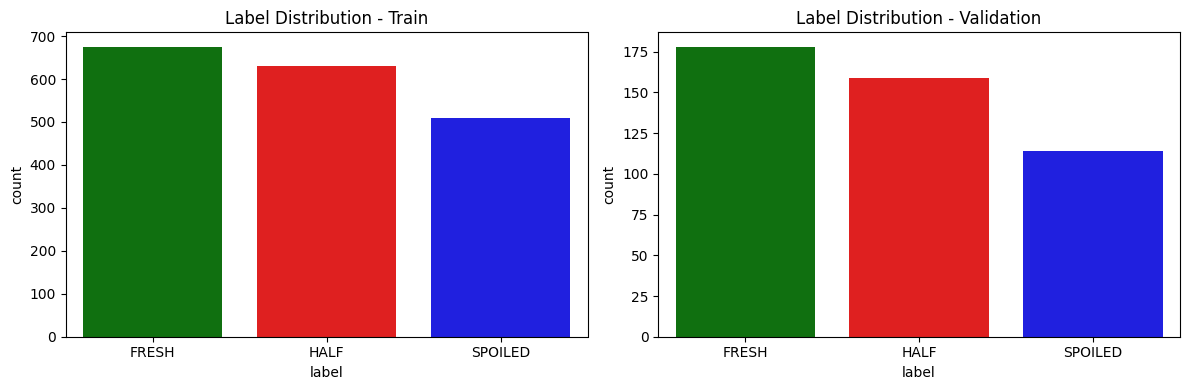

In [22]:
label_order = ['FRESH', 'HALF', 'SPOILED']
color_map = {'FRESH': 'green', 'HALF': 'red', 'SPOILED': 'blue'}
custom_palette = [color_map[l] for l in label_order]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df_train, x="label", order=label_order, ax=axes[0], palette=custom_palette)
axes[0].set_title("Label Distribution - Train")

sns.countplot(data=df_valid, x="label", order=label_order, ax=axes[1], palette=custom_palette)
axes[1].set_title("Label Distribution - Validation")

plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/label_distribution.png", dpi=300)
plt.show()


In [23]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import time


In [24]:
def plot_training_history(history):
    epochs = len(history.history['accuracy'])
    x = range(epochs)

    plt.figure(figsize=(12, 5))
    plt.plot(x, history.history['accuracy'], label='Train')
    plt.plot(x, history.history['val_accuracy'], label='Validation')
    plt.title("Training Accuracy")
    plt.legend()
    plt.savefig(f"{PROJECT_DIR}/training_history.png", dpi=300)
    plt.show()


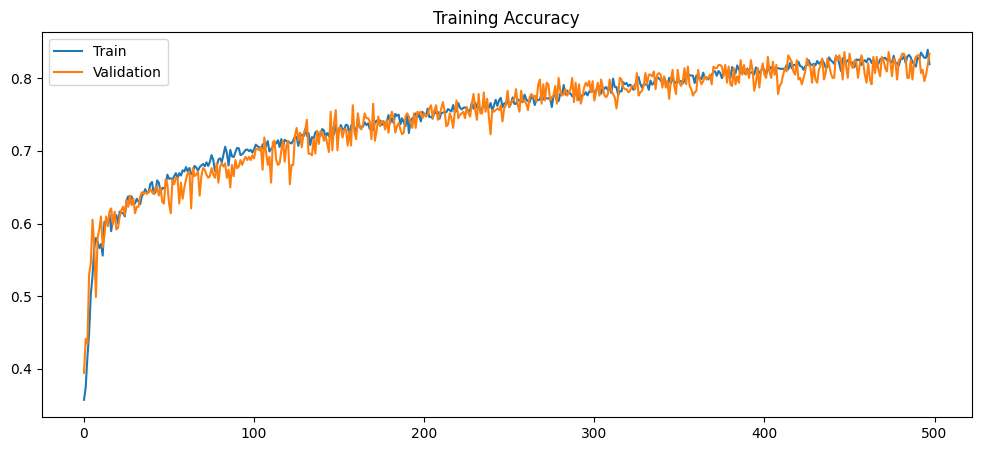

In [67]:
plot_training_history(history)

In [25]:
class myCallback(tf.keras.callbacks.Callback):
    def __init__(self, patience=50):
        self.patience = patience
        self.wait = 0
        self.best = 0

    def on_epoch_end(self, epoch, logs=None):
        if logs['val_accuracy'] > self.best:
            self.best = logs['val_accuracy']
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.model.stop_training = True


In [26]:
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    df_train, x_col='path', y_col='label',
    target_size=(224, 224), class_mode='categorical'
)

valid_generator = valid_datagen.flow_from_dataframe(
    df_valid, x_col='path', y_col='label',
    target_size=(224, 224), class_mode='categorical', shuffle=False
)


Found 1815 validated image filenames belonging to 3 classes.
Found 451 validated image filenames belonging to 3 classes.


In [27]:
def build_classifier(input_shape=(224,224,3), num_classes=3):
    inputs = tf.keras.Input(shape=input_shape)

    x = Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = MaxPooling2D()(x)
    x = Conv2D(64, 3, activation='relu', padding='same')(x)
    x = MaxPooling2D()(x)
    x = GlobalAveragePooling2D()(x)

    outputs = Dense(num_classes, activation='softmax')(x)
    return Model(inputs, outputs)


In [71]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,763 (229.55 KB)

 Trainable params: 19,587 (76.51 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 39,176 (153.04 KB)

In [28]:
model = build_classifier()
model.compile(
    optimizer=Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=1000,
    callbacks=[myCallback()]
)


Epoch 1/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 217s 4s/step - accuracy: 0.3075 - loss: 1.0991 - val_accuracy: 0.3947 - val_loss: 1.0819
Epoch 2/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 11s 189ms/step - accuracy: 0.3866 - loss: 1.0857 - val_accuracy: 0.4412 - val_loss: 1.0748
Epoch 3/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 181ms/step - accuracy: 0.4276 - loss: 1.0727 - val_accuracy: 0.4346 - val_loss: 1.0559
Epoch 4/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 21s 195ms/step - accuracy: 0.4277 - loss: 1.0523 - val_accuracy: 0.5299 - val_loss: 1.0541
Epoch 5/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 11s 191ms/step - accuracy: 0.5027 - loss: 1.0479 - val_accuracy: 0.5455 - val_loss: 1.0279
Epoch 6/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 11s 185ms/step - accuracy: 0.5195 - loss: 1.0229 - val_accuracy: 0.6053 - val_loss: 1.0161
Epoch 7/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 179ms/step - accuracy: 0.5820 - loss: 1.0146 - val_accuracy: 0.5721 - val_loss: 0.9981
Epoch 8/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 11s 191ms/step - accuracy: 0.5899 - loss: 0.9

In [29]:
model.save(f"{PROJECT_DIR}/meat_freshness_model.keras", include_optimizer=False)
model.save(f"{PROJECT_DIR}/meat_freshness_model.h5", include_optimizer=False)

print("Model saved to Google Drive")


Model saved to Google Drive


In [30]:
import json
with open(f"{PROJECT_DIR}/class_indices.json", "w") as f:
    json.dump(train_generator.class_indices, f)


In [31]:
val_loss, val_acc = model.evaluate(valid_generator, verbose=0)

with open(f"{PROJECT_DIR}/results.txt", "w") as f:
    f.write(f"Accuracy: {val_acc*100:.2f}%\n")
    f.write(f"Loss: {val_loss:.4f}\n")

print("Evaluation saved")


Evaluation saved


In [32]:
!ls -lh "$PROJECT_DIR"


total 448K
-rw------- 1 root root   37 Mar  2 14:02 class_indices.json
-rw------- 1 root root  82K Mar  2 12:25 label_distribution.png
-rw------- 1 root root 101K Mar  2 14:02 meat_freshness_model.h5
-rw------- 1 root root 265K Mar  2 14:02 meat_freshness_model.keras
-rw------- 1 root root   30 Mar  2 14:02 results.txt


📤 Please upload an image file...


Saving SPOILED-259-_JPG.rf.2e197359c5e5a601d0caa90bf5473618.jpg to SPOILED-259-_JPG.rf.2e197359c5e5a601d0caa90bf5473618.jpg


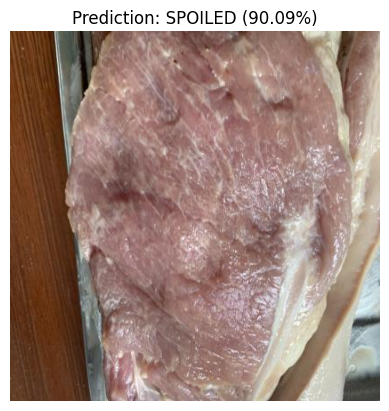

✅ Predicted class: SPOILED
✅ Confidence: 90.09%


In [33]:
#Test Model

import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from google.colab import files
import os

MODEL_PATH = f"{PROJECT_DIR}/meat_freshness_model.keras"
CLASS_MAP_PATH = f"{PROJECT_DIR}/class_indices.json"

model = load_model(MODEL_PATH)

with open(CLASS_MAP_PATH, "r") as f:
    class_indices = json.load(f)

idx_to_class = {v: k for k, v in class_indices.items()}

def predict_uploaded_image():
    print("📤 Please upload an image file...")
    uploaded = files.upload()

    if not uploaded:
        print("❌ No image uploaded.")
        return

    image_path = list(uploaded.keys())[0]

    img = cv2.imread(image_path)
    if img is None:
        print("❌ Failed to read the uploaded image.")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_norm = img_resized / 255.0
    img_input = np.expand_dims(img_norm, axis=0)

    pred = model.predict(img_input, verbose=0)
    class_id = np.argmax(pred)
    confidence = pred[0][class_id] * 100
    label = idx_to_class[class_id]

    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"Prediction: {label} ({confidence:.2f}%)")
    plt.show()

    print("✅ Predicted class:", label)
    print(f"✅ Confidence: {confidence:.2f}%")

predict_uploaded_image()


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - accuracy: 0.8148 - loss: 0.4202

===== MODEL PERFORMANCE =====
Validation Accuracy: 0.8337
Validation Loss    : 0.4031

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

       FRESH       0.78      0.83      0.80       178
        HALF       0.78      0.73      0.76       159
     SPOILED       0.99      0.98      0.99       114

    accuracy                           0.83       451
   macro avg       0.85      0.85      0.85       451
weighted avg       0.83      0.83      0.83       451



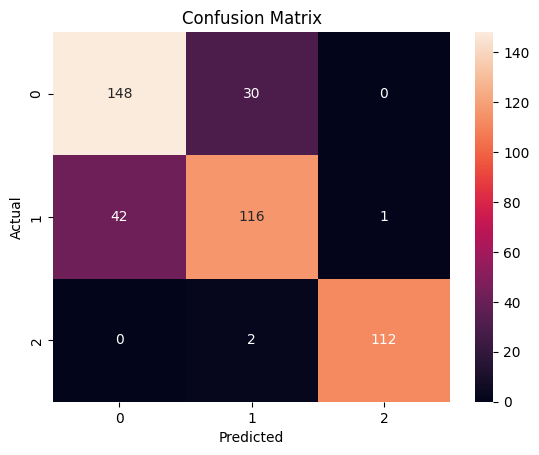

In [45]:
#Model Evaluation

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

loss, accuracy = model.evaluate(valid_generator, verbose=1)

print("\n===== MODEL PERFORMANCE =====")
print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation Loss    : {loss:.4f}")

valid_generator.reset()
y_pred_probs = model.predict(valid_generator, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = valid_generator.classes
class_labels = list(valid_generator.class_indices.keys())

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_true, y_pred, target_names=class_labels))

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [54]:
# GRAD-CAM

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files
import json

with open(CLASS_MAP_PATH, "r") as f:
    class_indices = json.load(f)

idx_to_class = {v: k for k, v in class_indices.items()}


def run_gradcam_visual():

    print("📤 Upload an image...")
    uploaded = files.upload()

    if not uploaded:
        print("❌ No image uploaded.")
        return

    image_path = list(uploaded.keys())[0]

    img = cv2.imread(image_path)
    if img is None:
        print("❌ Could not read image.")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_array = np.expand_dims(img_resized / 255.0, axis=0)

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer("conv2d_1").output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    heatmap = heatmap.numpy()

    predicted_class = np.argmax(predictions.numpy()[0])
    confidence = float(predictions.numpy()[0][predicted_class]) * 100
    predicted_label = idx_to_class[predicted_class]

    heatmap_resized = cv2.resize(heatmap, (img_rgb.shape[1], img_rgb.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(img_rgb, 0.6, heatmap_color, 0.4, 0)

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(heatmap_resized, cmap='jet')
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(overlay)
    plt.title(f"Overlay\n{predicted_label} ({confidence:.2f}%)")
    plt.axis("off")

    plt.show()

    print("Final Prediction:", predicted_label)
    print(f"Confidence: {confidence:.2f}%")

📤 Upload an image...


Saving FRESH-720-_JPG.rf.e511b594ee157ea87734ef9b3efd7c18.jpg to FRESH-720-_JPG.rf.e511b594ee157ea87734ef9b3efd7c18.jpg


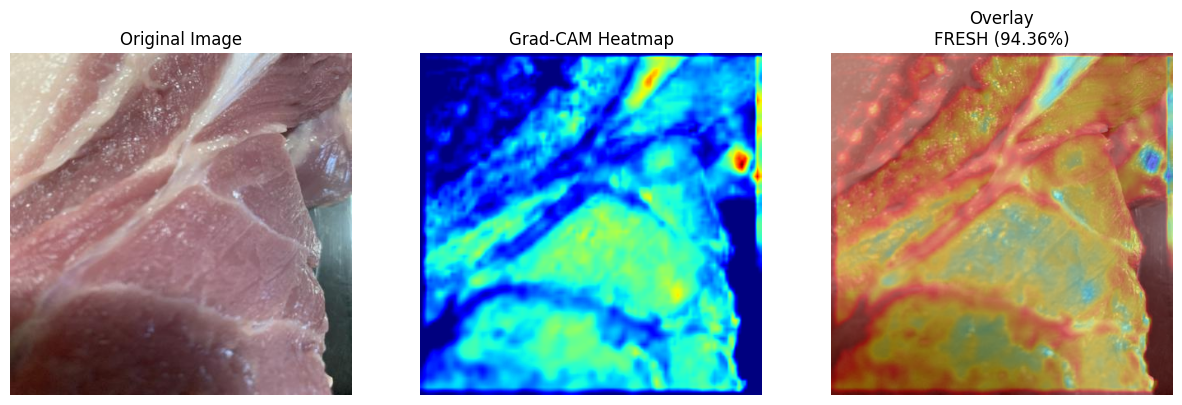

Final Prediction: FRESH
Confidence: 94.36%


In [57]:
run_gradcam_visual()

In [58]:
#Spoilage Localization

import json

with open(CLASS_MAP_PATH, "r") as f:
    class_indices = json.load(f)

idx_to_class = {v: k for k, v in class_indices.items()}


def detect_spoilage_uploaded(threshold=0.6):

    print("📤 Upload an image...")
    uploaded = files.upload()

    if not uploaded:
        print("❌ No image uploaded.")
        return

    image_path = list(uploaded.keys())[0]

    img = cv2.imread(image_path)

    if img is None:
        print("❌ Could not read image.")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    original_h, original_w = img_rgb.shape[:2]

    img_resized = cv2.resize(img_rgb, (224, 224))
    img_array = np.expand_dims(img_resized / 255.0, axis=0)

    heatmap, predictions = make_gradcam_heatmap(
        img_array, model, "conv2d_1"
    )

    predicted_class = np.argmax(predictions)
    class_confidence = float(predictions[predicted_class]) * 100
    predicted_label = idx_to_class[predicted_class]

    heatmap = cv2.resize(heatmap, (original_w, original_h))
    heatmap_binary = np.uint8(heatmap > threshold) * 255

    contours, _ = cv2.findContours(
        heatmap_binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    output_image = img_rgb.copy()

    if predicted_label == "SPOILED":
        box_color = (255, 0, 0)
    elif predicted_label == "FRESH":
        box_color = (0, 255, 0)
    else:
        box_color = (255, 165, 0)

    region_count = 1

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)

        if w * h > 500:

            region_heatmap = heatmap[y:y+h, x:x+w]
            region_score = np.mean(region_heatmap) * class_confidence

            label_text = f"{predicted_label} R{region_count}: {region_score:.2f}%"

            cv2.rectangle(output_image, (x, y), (x+w, y+h), box_color, 3)

            cv2.putText(
                output_image,
                label_text,
                (x, y-5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                box_color,
                2
            )

            region_count += 1

    plt.figure(figsize=(8,6))
    plt.imshow(output_image)
    plt.axis("off")
    plt.title(f"Prediction: {predicted_label} ({class_confidence:.2f}%)")
    plt.show()

    print("Final Prediction:", predicted_label)
    print(f"Confidence: {class_confidence:.2f}%")

📤 Upload an image...


Saving FRESH-90-_JPG.rf.0bb27f22b1550a15c071db138b6332b3.jpg to FRESH-90-_JPG.rf.0bb27f22b1550a15c071db138b6332b3.jpg


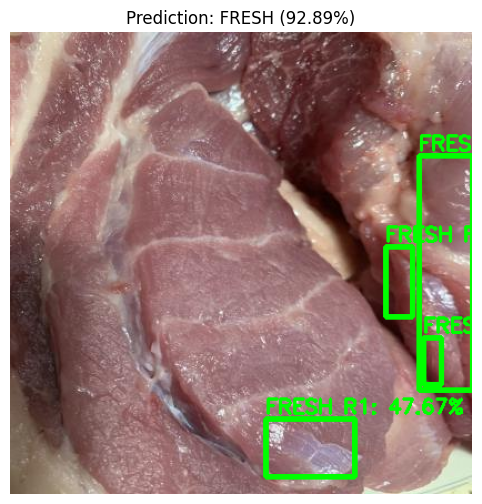

Final Prediction: FRESH
Confidence: 92.89%


In [66]:
detect_spoilage_uploaded()